# Imbalance Handling for Loan Default Prediction

This notebook evaluates multiple imbalance handling techniques:
- Baseline (No Sampling)
- Random Under Sampling (RUS)
- SMOTE
- SMOTE-ENN


## Import Required Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Cleaned Dataset

In [68]:
df = pd.read_csv("loan_default_final_ready.csv")
df.shape


(100000, 105)

## Dataset Overview

In [69]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 105 entries, loan_amnt to loan_default
dtypes: float64(39), int64(47), object(19)
memory usage: 80.1+ MB


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,deferral_term,payment_plan_start_date,orig_projected_additional_accrued_interest,disbursement_method,loan_default
0,15000,15000,15000,60 months,11.53,330.12,B,B5,Right of way agent,4 years,...,0,357481,114278,19600,106275,3.0,Oct-17,299.19,Cash,1
1,25600,25600,25600,60 months,27.88,795.23,G,G3,Teacher,10+ years,...,0,41673,34314,16300,21373,3.0,Oct-17,299.19,Cash,1
2,6000,6000,6000,36 months,15.41,209.20,D,D1,Outfitter,< 1 year,...,0,54878,51560,6100,41278,3.0,Oct-17,299.19,Cash,0
3,5000,5000,5000,36 months,9.99,161.32,B,B3,Courier,10+ years,...,0,74769,10653,20000,22769,3.0,Oct-17,299.19,Cash,0
4,12000,12000,12000,60 months,8.38,245.51,B,B1,IT Specialist,10+ years,...,0,189700,19637,20000,0,3.0,Oct-17,299.19,Cash,1


## Analyze Class Distribution

In [71]:
df['loan_default'].value_counts()
df['loan_default'].value_counts(normalize=True)


loan_default
0    0.70475
1    0.29525
Name: proportion, dtype: float64

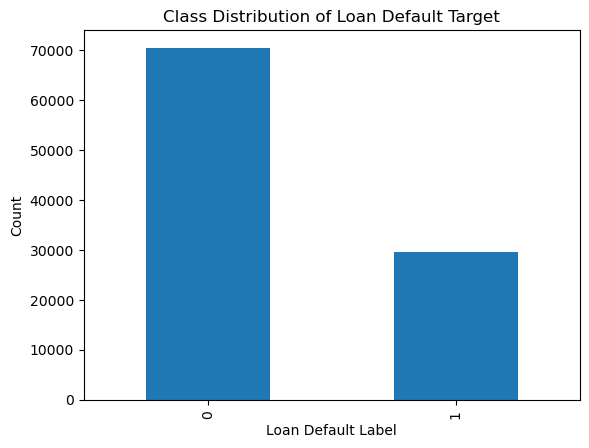

In [ ]:
df['loan_default'].value_counts().plot(kind='bar')
plt.title("Class Distribution of Loan Default Target")
plt.xlabel("Loan Default Label")
plt.ylabel("Count")
plt.show()
# Visualize imbalance in target classes
# 0 for Non default, 1 for Default

## Separate Features and Target Variable

In [73]:
X = df.drop('loan_default', axis=1)
y = df['loan_default']


## Stratified Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Preserve class distribution using stratified split

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


(80000, 104) (20000, 104)
loan_default
0    0.70475
1    0.29525
Name: proportion, dtype: float64
loan_default
0    0.70475
1    0.29525
Name: proportion, dtype: float64


## Identify Numerical and Categorical Features

In [76]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

print(len(cat_cols), len(num_cols))


19 85


## Build Preprocessing Pipeline

In [81]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
    ]
)


In [82]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('classifier', LogisticRegression(
            max_iter=1000,
            solver='saga',      # supports sparse
            n_jobs=-1
        ))
    ]
)


In [ ]:
baseline_model.fit(X_train, y_train)
print("Model fitted successfully")
# Train baseline model without sampling

Model fitted successfully


D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


The baseline model was trained without any imbalance handling to establish a reference performance benchmark.

## Evaluate Baseline Model

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

# Core metrics
print("Baseline Model Performance")
print("-" * 30)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Baseline Model Performance
------------------------------
Accuracy : 0.93745
Precision: 0.9109855174849877
Recall   : 0.8734970364098222
F1-score : 0.8918474971902827
ROC-AUC  : 0.9795441781139774

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     14095
           1       0.91      0.87      0.89      5905

    accuracy                           0.94     20000
   macro avg       0.93      0.92      0.92     20000
weighted avg       0.94      0.94      0.94     20000


Confusion Matrix:
[[13591   504]
 [  747  5158]]


## Import Imbalance Handling Techniques

In [87]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


## Define Training and Evaluation Function

In [ ]:
def train_and_evaluate(X_tr, y_tr, X_te, y_te, label):
    model = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('classifier', LogisticRegression(
                max_iter=1000,
                solver='saga',
                n_jobs=-1
            ))
        ]
    )
    # Train Logistic Regression model with preprocessing
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    print(f"\n===== {label} =====")
    print(classification_report(y_te, y_pred))
    print("ROC-AUC:", roc_auc_score(y_te, y_prob))


## Random Under Sampling (RUS)

In [89]:
#RUS
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("RUS class distribution:")
print(y_train_rus.value_counts())


RUS class distribution:
loan_default
0    23620
1    23620
Name: count, dtype: int64


In [90]:
train_and_evaluate(
    X_train_rus, y_train_rus,
    X_test, y_test,
    label="Logistic Regression + RUS"
)


D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== Logistic Regression + RUS =====
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     14095
           1       0.86      0.93      0.89      5905

    accuracy                           0.93     20000
   macro avg       0.91      0.93      0.92     20000
weighted avg       0.94      0.93      0.93     20000

ROC-AUC: 0.9792051216509239


## SMOTE Oversampling

In [95]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

smote_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            solver="saga",
            n_jobs=-1
        ))
    ]
)

smote_pipeline.fit(X_train, y_train)

D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_...
       'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan',
       'purpose', 'zip_code', 'addr_state', 'earliest_cr_line',
       'initial_list_status', 'last_credit_pull_d', 'application_type',
       'verification_status_joint', 'payment_plan_start_date',
       'disbursement_method'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, n_jobs=-1, solver='saga'))])

In [96]:
y_pred = smote_pipeline.predict(X_test)
y_prob = smote_pipeline.predict_proba(X_test)[:, 1]

print("===== Logistic Regression + SMOTE =====")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

===== Logistic Regression + SMOTE =====
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     14095
           1       0.87      0.92      0.89      5905

    accuracy                           0.93     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.94      0.93      0.93     20000

ROC-AUC: 0.9791178224212803


## SMOTE-ENN Hybrid Sampling

In [98]:
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

smoteenn_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('smoteenn', SMOTEENN(random_state=42)),
        ('classifier', LogisticRegression(
            max_iter=1000,
            solver='saga',
            n_jobs=-1
        ))
    ]
)


In [99]:
smoteenn_pipeline.fit(X_train, y_train)


D:\anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_...
       'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan',
       'purpose', 'zip_code', 'addr_state', 'earliest_cr_line',
       'initial_list_status', 'last_credit_pull_d', 'application_type',
       'verification_status_joint', 'payment_plan_start_date',
       'disbursement_method'],
      dtype='object'))])),
                ('smoteenn', SMOTEENN(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, n_jobs=-1, solver='saga'))])

## Evaluate SMOTE-ENN Model

In [100]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = smoteenn_pipeline.predict(X_test)
y_prob = smoteenn_pipeline.predict_proba(X_test)[:, 1]

print("===== Logistic Regression + SMOTE-ENN =====")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


===== Logistic Regression + SMOTE-ENN =====
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     14095
           1       0.74      0.97      0.84      5905

    accuracy                           0.89     20000
   macro avg       0.86      0.91      0.88     20000
weighted avg       0.91      0.89      0.89     20000

ROC-AUC: 0.9765892445691041


## Save Preprocessing Artifacts

In [147]:
import joblib

joblib.dump(preprocess, "preprocess_pipeline.pkl")
joblib.dump(X.columns.tolist(), "raw_feature_columns.pkl")

['raw_feature_columns.pkl']